Want to get better at SciPy?

Here’s a practical SciPy Interactive Cheatsheet covering statistics, probability, hypothesis testing, correlation, optimization, and root finding — with runnable Python examples and visualizations.

🧵 Let’s break it down 👇


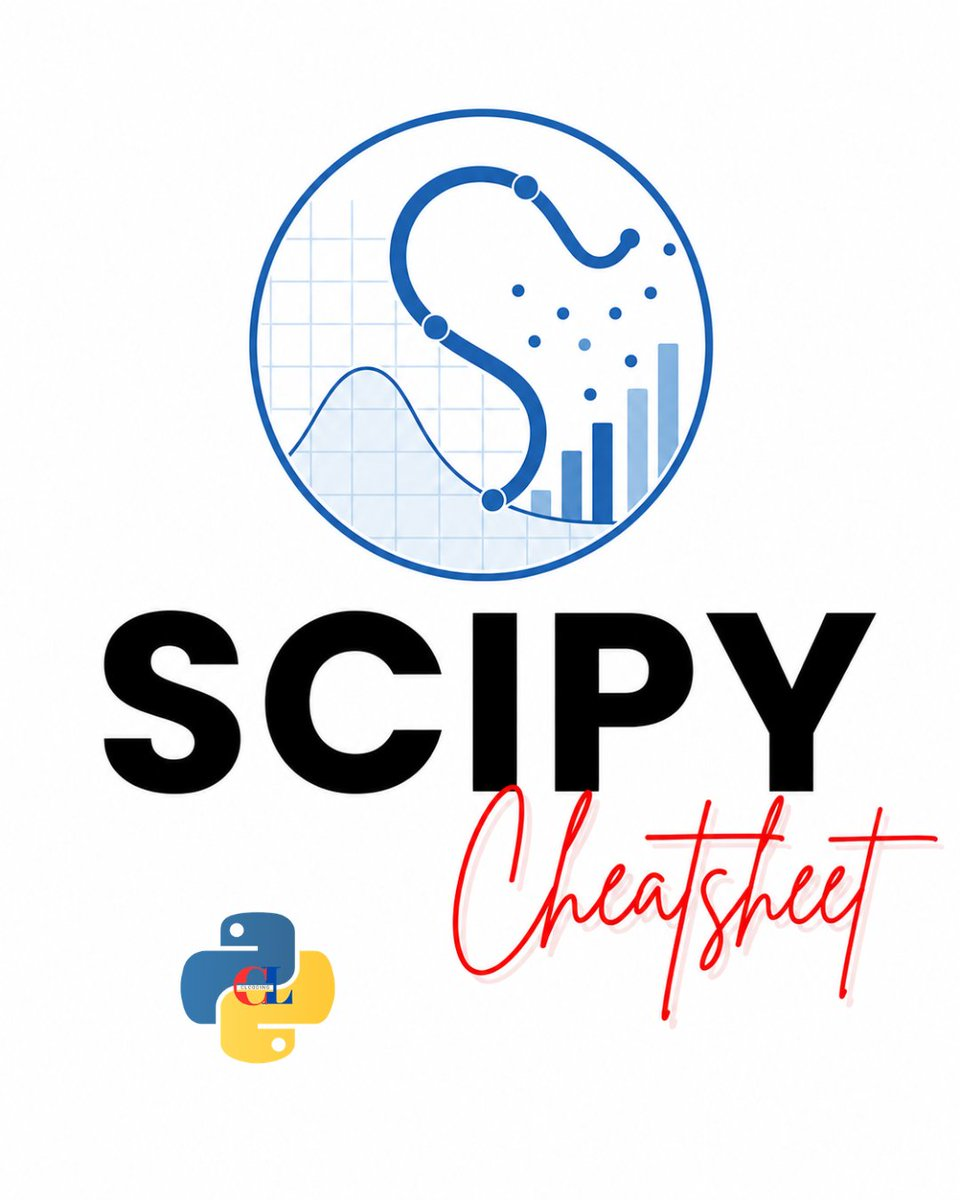

In [3]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/


https://x.com/clcoding/status/2095199468706766944

🧪 SciPy — Interactive Cheatsheet

This visual guide covers:

📊 Statistics
🎲 Probability
🧠 Hypothesis Testing
📈 Correlation
⚙️ Optimization
🎯 Root Finding
🔢 Integration
📐 Interpolation
📏 Distance
🧮 Linear Algebra
📡 Signal Processing
A great reference for Python, Data Science & ML.


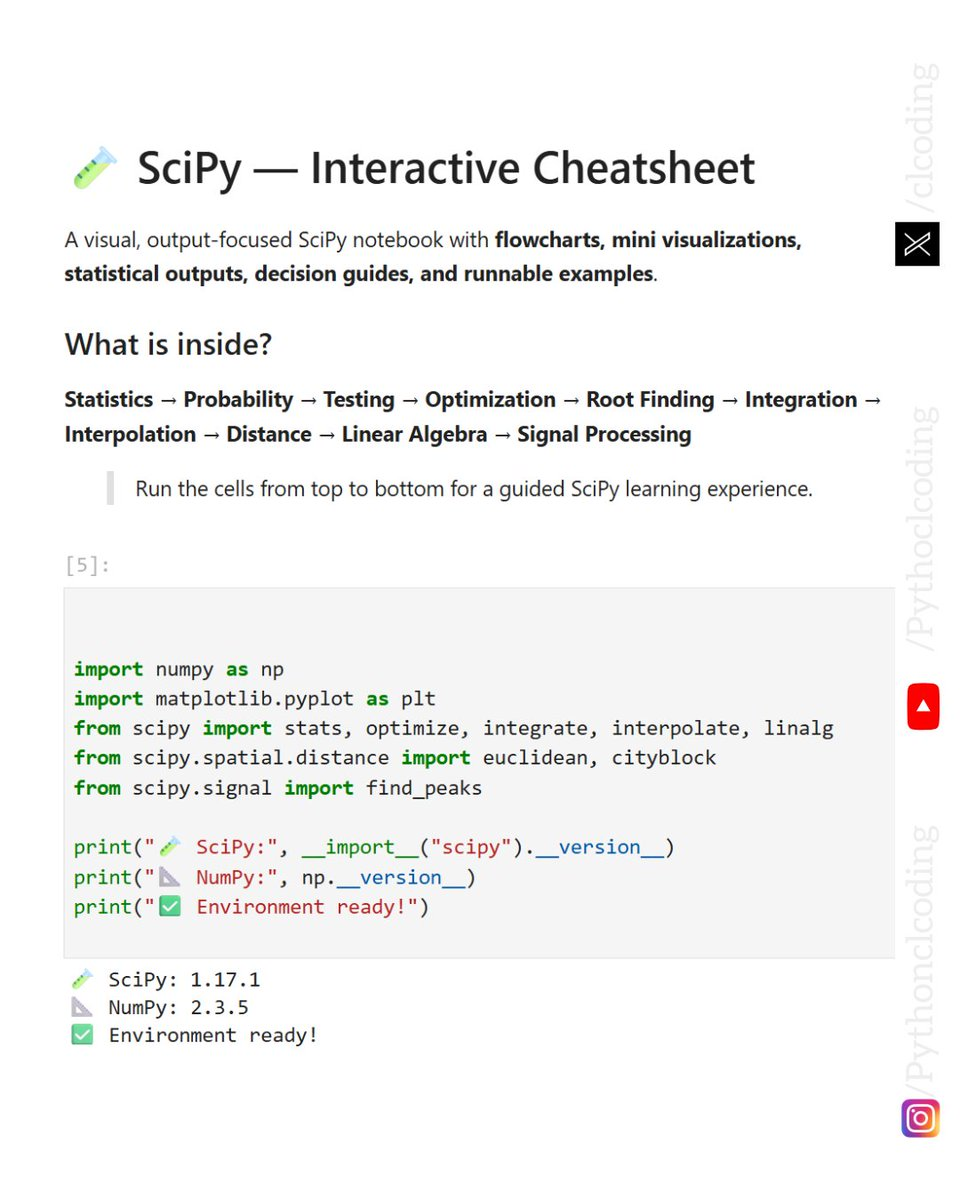

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize, integrate, interpolate, linalg
from scipy.spatial.distance import euclidean, cityblock
from scipy.signal import find_peaks

print("🧪 SciPy:", __import__("scipy").__version__)
print("📐 NumPy:", np.__version__)
print("✅ Environment ready!")

🧪 SciPy: 1.17.1
📐 NumPy: 2.3.5
✅ Environment ready!


📊 1. Descriptive Statistics

SciPy’s stats module makes it easy to summarize and analyze data.

You can calculate:

• Mean
• Median
• Minimum / Maximum
• Standard deviation
Perfect for quickly understanding a dataset before deeper analysis.



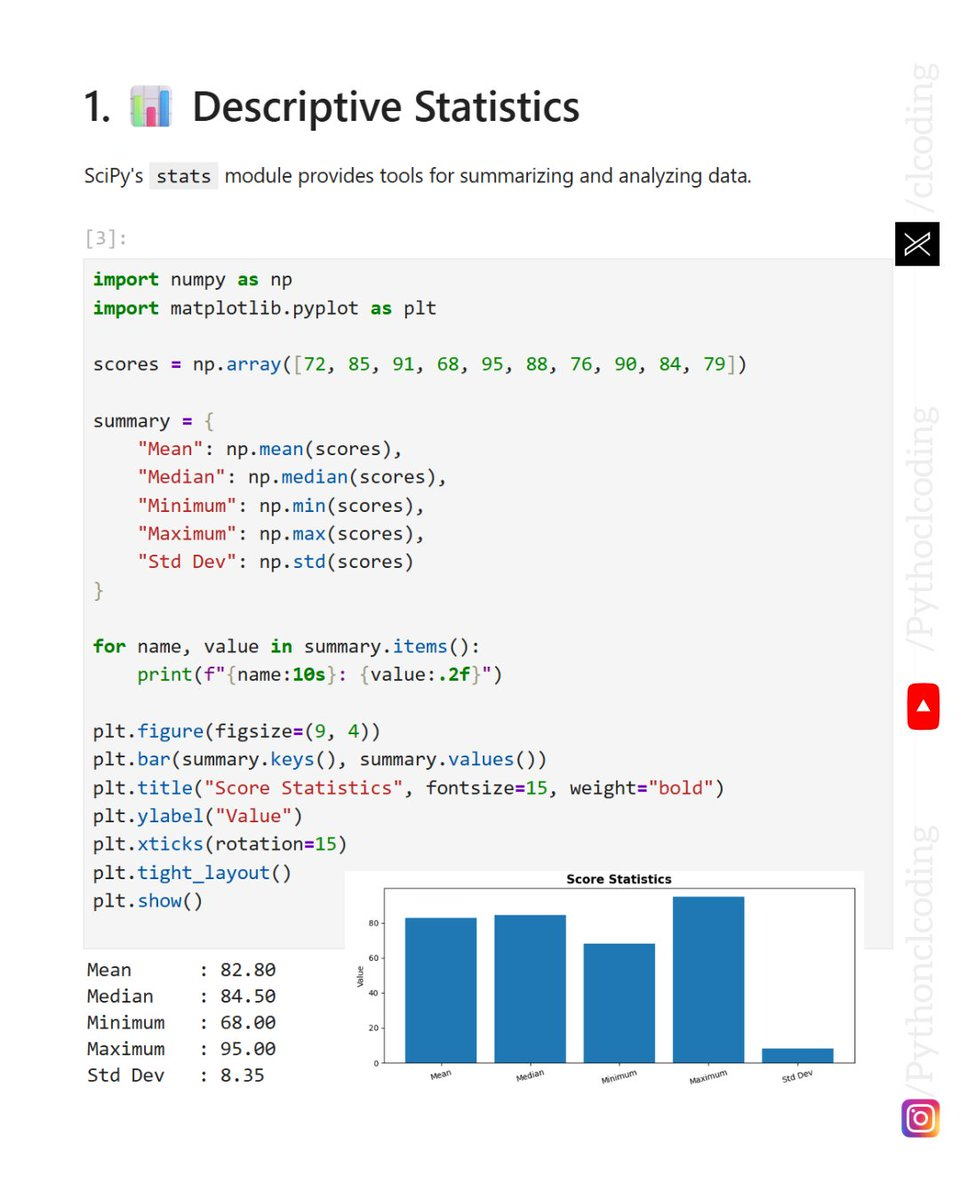

Mean      : 82.80
Median    : 84.50
Minimum   : 68.00
Maximum   : 95.00
Std Dev   : 8.35


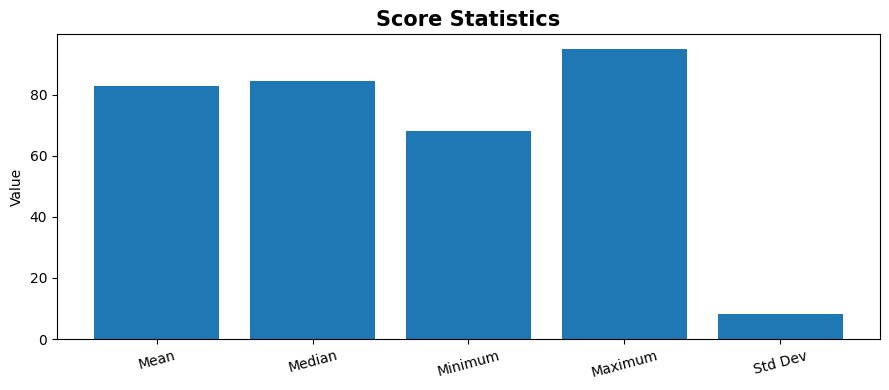

In [4]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.array([72, 85, 91, 68, 95, 88, 76, 90, 84, 79])

summary = {
    "Mean": np.mean(scores),
    "Median": np.median(scores),
    "Minimum": np.min(scores),
    "Maximum": np.max(scores),
    "Std Dev": np.std(scores)
}

for name, value in summary.items():
    print(f"{name:10s}: {value:.2f}")

plt.figure(figsize=(9, 4))
plt.bar(summary.keys(), summary.values())
plt.title("Score Statistics", fontsize=15, weight="bold")
plt.ylabel("Value")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

🎲 2. Probability Distributions

SciPy provides ready-to-use probability distributions such as:

• Normal
• Binomial
• Poisson
• Uniform
You can calculate probabilities, densities, percentiles, and more with just a few lines of Python.

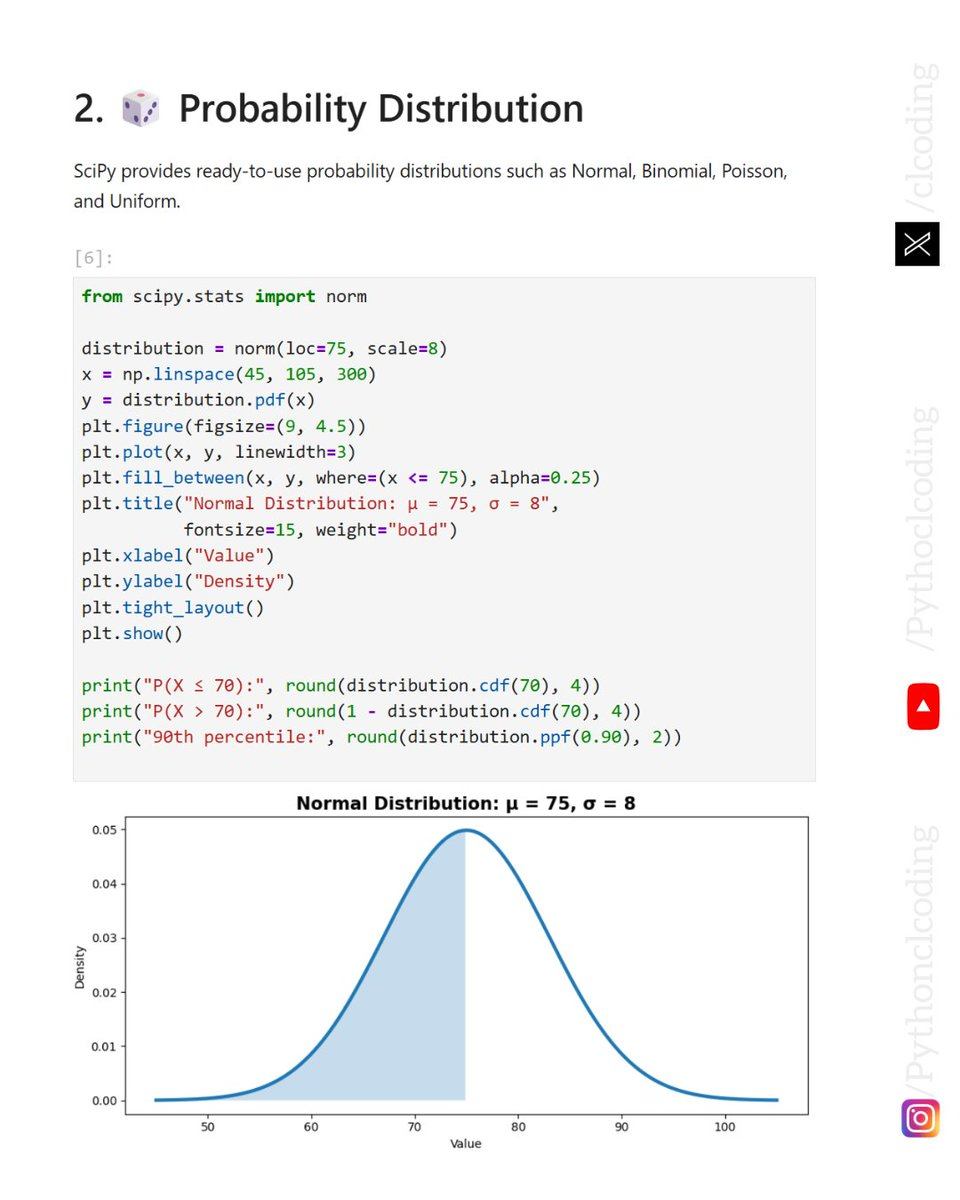

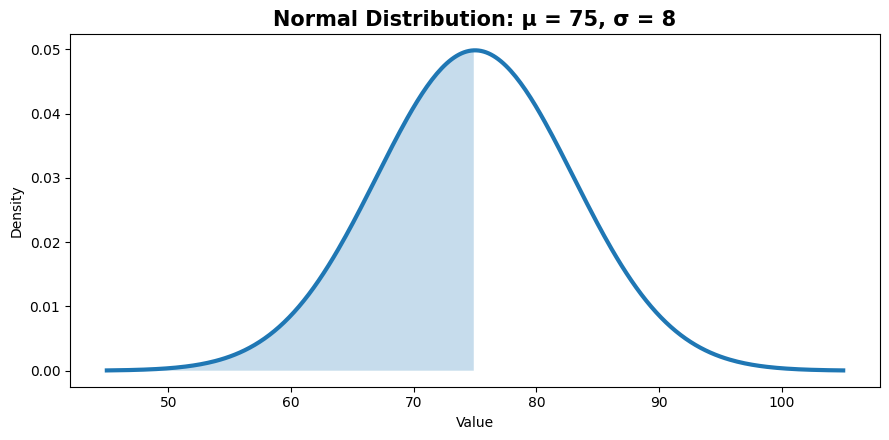

P(X ≤ 70): 0.266
P(X > 70): 0.734
90th percentile: 85.25


In [5]:
from scipy.stats import norm

distribution = norm(loc=75, scale=8)
x = np.linspace(45, 105, 300)
y = distribution.pdf(x)

plt.figure(figsize=(9, 4.5))
plt.plot(x, y, linewidth=3)
plt.fill_between(x, y, where=(x <= 75), alpha=0.25)
plt.title("Normal Distribution: μ = 75, σ = 8",
          fontsize=15, weight="bold")
plt.xlabel("Value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print("P(X ≤ 70):", round(distribution.cdf(70), 4))
print("P(X > 70):", round(1 - distribution.cdf(70), 4))
print("90th percentile:", round(distribution.ppf(0.90), 2))

🧠 3. Hypothesis Testing

Statistical tests help determine whether your data provides enough evidence against a null hypothesis.

Example:

stats.ttest_1samp()

The output gives you a t-statistic and p-value, which can guide your statistical decision.


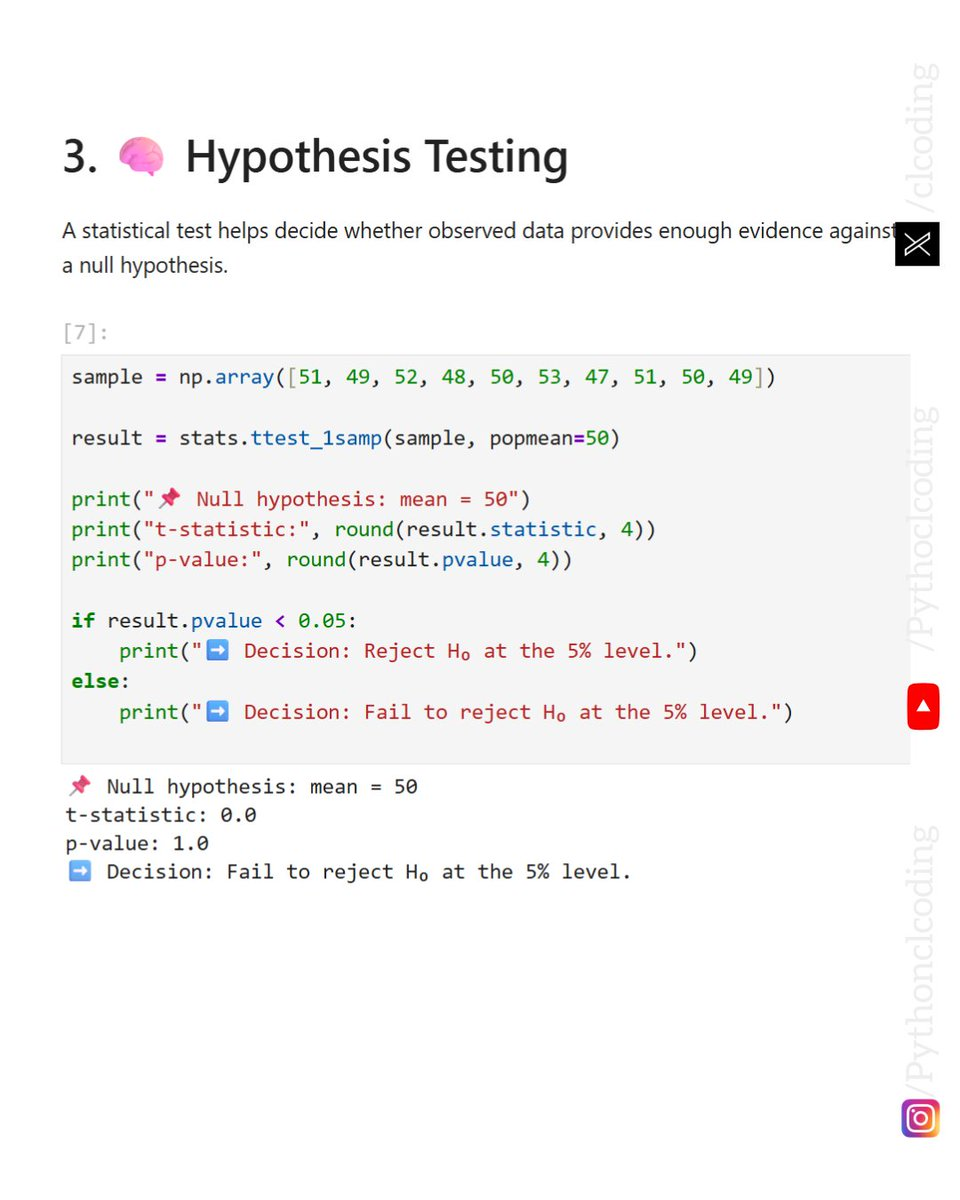



In [6]:
sample = np.array([51, 49, 52, 48, 50, 53, 47, 51, 50, 49])

result = stats.ttest_1samp(sample, popmean=50)

print("📌 Null hypothesis: mean = 50")
print("t-statistic:", round(result.statistic, 4))
print("p-value:", round(result.pvalue, 4))

if result.pvalue < 0.05:
    print("➡️ Decision: Reject H₀ at the 5% level.")
else:
    print("➡️ Decision: Fail to reject H₀ at the 5% level.")

📌 Null hypothesis: mean = 50
t-statistic: 0.0
p-value: 1.0
➡️ Decision: Fail to reject H₀ at the 5% level.


📈 4. Correlation

Want to measure the relationship between two variables?

SciPy provides:

stats.pearsonr() → measures linear association

stats.spearmanr() → measures rank-based association

In the example, study hours and marks show a very strong positive relationship.


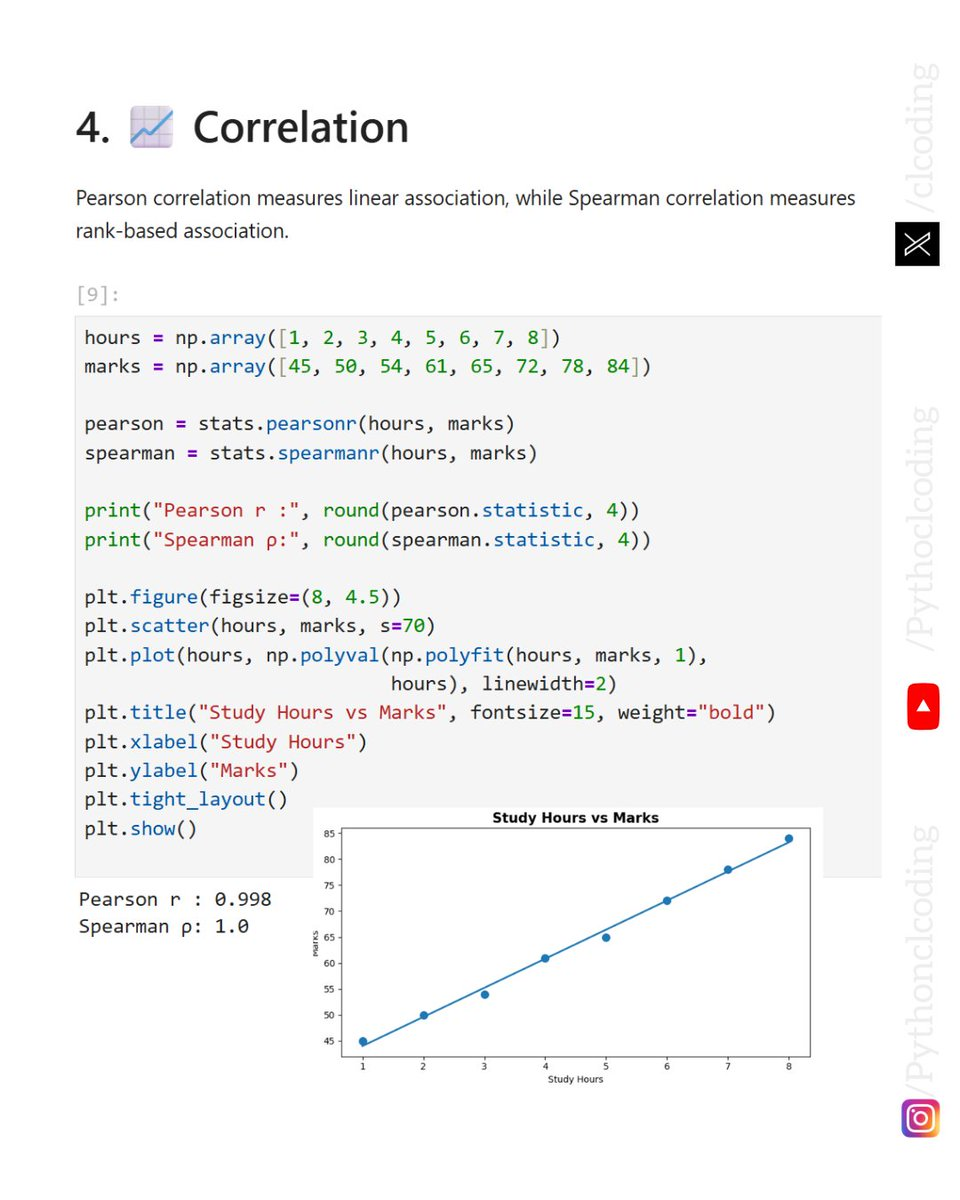

Pearson r : 0.998
Spearman ρ: 1.0


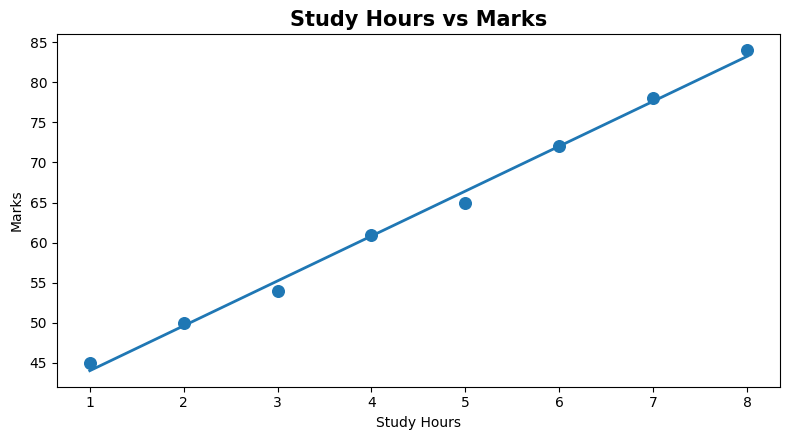

In [7]:
hours = np.array([1, 2, 3, 4, 5, 6, 7, 8])
marks = np.array([45, 50, 54, 61, 65, 72, 78, 84])

pearson = stats.pearsonr(hours, marks)
spearman = stats.spearmanr(hours, marks)

print("Pearson r :", round(pearson.statistic, 4))
print("Spearman ρ:", round(spearman.statistic, 4))

plt.figure(figsize=(8, 4.5))
plt.scatter(hours, marks, s=70)
plt.plot(hours, np.polyval(np.polyfit(hours, marks, 1),
                          hours), linewidth=2)
plt.title("Study Hours vs Marks", fontsize=15, weight="bold")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.tight_layout()
plt.show()

⚙️ 5. Optimization

Optimization is about finding the input that minimizes or maximizes an objective function.

SciPy’s:

optimize.minimize()

can solve optimization problems efficiently.

In this example, the minimum occurs at x = 4 with an objective value of 3.


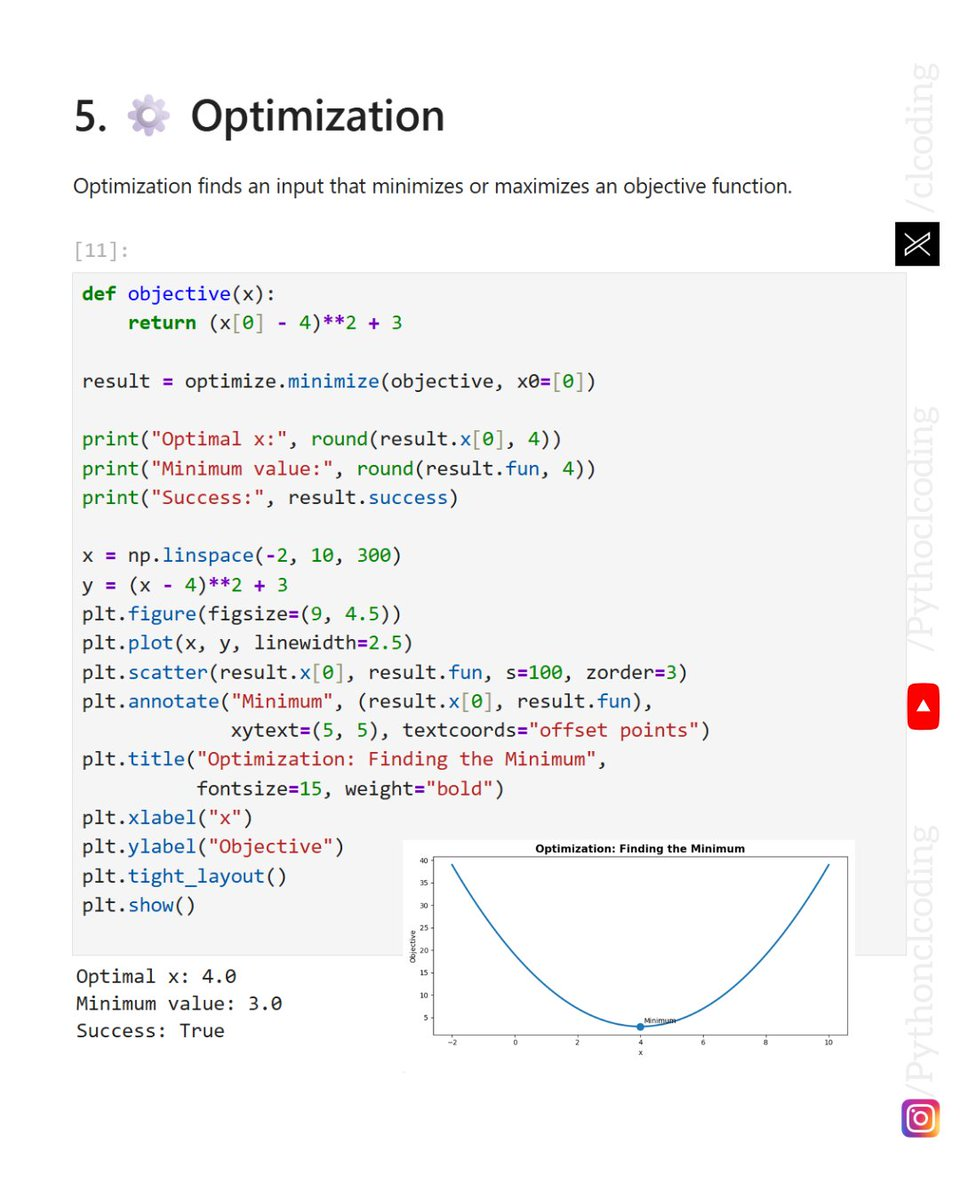

Optimal x: 4.0
Minimum value: 3.0
Success: True


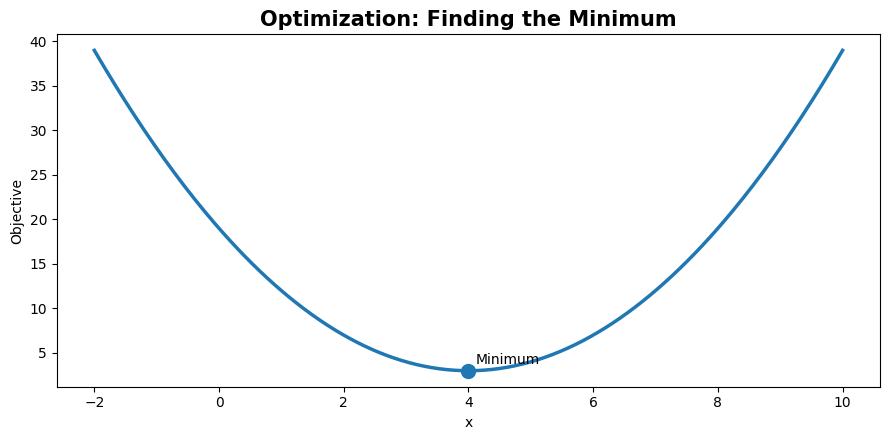

In [8]:
def objective(x):
    return (x[0] - 4)**2 + 3

result = optimize.minimize(objective, x0=[0])

print("Optimal x:", round(result.x[0], 4))
print("Minimum value:", round(result.fun, 4))
print("Success:", result.success)

x = np.linspace(-2, 10, 300)
y = (x - 4)**2 + 3

plt.figure(figsize=(9, 4.5))
plt.plot(x, y, linewidth=2.5)
plt.scatter(result.x[0], result.fun, s=100, zorder=3)
plt.annotate("Minimum", (result.x[0], result.fun),
             xytext=(5, 5), textcoords="offset points")
plt.title("Optimization: Finding the Minimum",
          fontsize=15, weight="bold")
plt.xlabel("x")
plt.ylabel("Objective")
plt.tight_layout()
plt.show()


🎯 6. Root Finding

A root is a value where a function equals zero.

Using:

optimize.root_scalar()

we can find the root of:

x² - 25 = 0

The example finds:

Root = 5

SciPy makes numerical methods accessible with just a few lines of Python.

🐍 Save this thread as a quick SciPy reference.


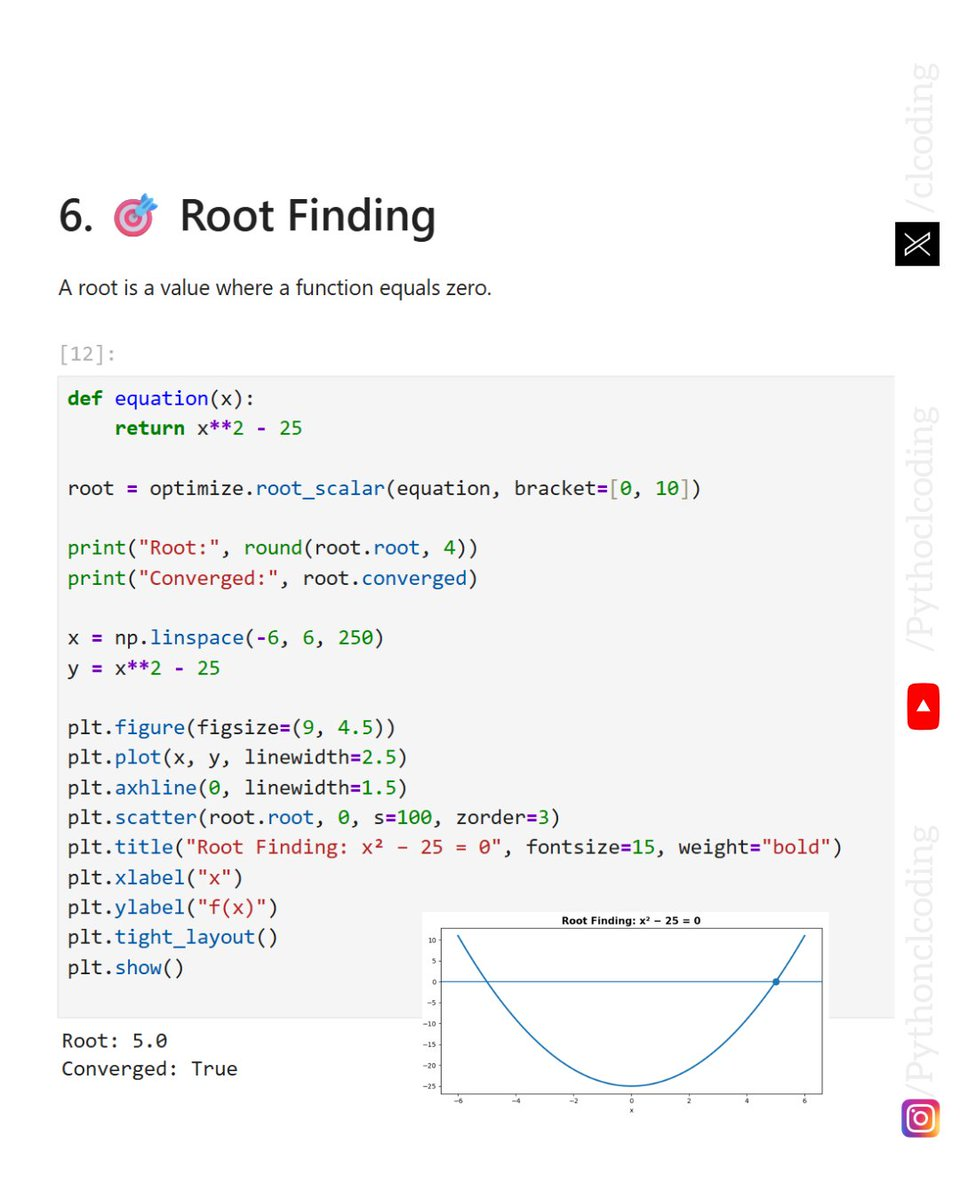

Root: 5.0
Converged: True


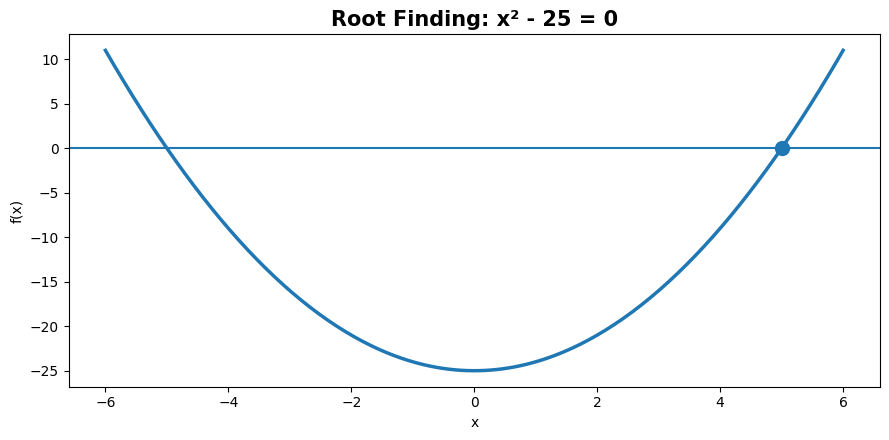

In [9]:
def equation(x):
    return x**2 - 25

root = optimize.root_scalar(equation, bracket=[0, 10])

print("Root:", round(root.root, 4))
print("Converged:", root.converged)

x = np.linspace(-6, 6, 250)
y = x**2 - 25

plt.figure(figsize=(9, 4.5))
plt.plot(x, y, linewidth=2.5)
plt.axhline(0, linewidth=1.5)
plt.scatter(root.root, 0, s=100, zorder=3)
plt.title("Root Finding: x² - 25 = 0", fontsize=15, weight="bold")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.tight_layout()
plt.show()

**SciPy can help you turn network measurements into decisions:** Is latency getting worse? Is packet loss unusually high? When do traffic spikes happen? How should traffic be split across links?

These four examples use sample data and run independently in VS Code.

First, install the libraries in the VS Code terminal:

```bash
python -m pip install numpy scipy matplotlib
```

Save each example as a separate `.py` file and run it, for example:

```bash
python latency_analysis.py
```

**1. Analyze latency: “Does this link have occasional slow responses?”**

An average alone can hide slow responses. This example compares the mean, median, and 95th percentile.

```python
import numpy as np
from scipy import stats

# Sample ping round-trip times in milliseconds.
rtt = np.array([
    12, 13, 11, 14, 12, 13, 15, 12, 11, 14,
    13, 12, 16, 14, 13, 12, 15, 14, 80, 120
])

summary = stats.describe(rtt)

print(f"Samples: {summary.nobs}")
print(f"Minimum: {summary.minmax[0]:.1f} ms")
print(f"Maximum: {summary.minmax[1]:.1f} ms")
print(f"Mean: {summary.mean:.1f} ms")
print(f"Median: {np.median(rtt):.1f} ms")
print(f"95th percentile: {np.percentile(rtt, 95):.1f} ms")
print(f"Sample standard deviation: {np.sqrt(summary.variance):.1f} ms")

# Fraction of observed responses exceeding a chosen threshold.
threshold_ms = 50
slow_percent = np.mean(rtt > threshold_ms) * 100

print(f"Responses above {threshold_ms} ms: {slow_percent:.1f}%")
```

From a network engineer’s perspective:

- **Median:** A typical response—here, **13.5 ms**.
- **Mean:** **22.6 ms**, pulled upward by the slow responses.
- **P95:** **82 ms** with NumPy’s default interpolation. This describes the upper tail of this small sample.
- **Standard deviation:** How spread out the RTT measurements are; this is not automatically the same as a protocol’s jitter metric.

**Try this:** Replace `80, 120` with `14, 15`. Watch how much the mean and P95 change compared with the median.

**2. Test packet loss: “Is the loss rate higher than our 1% baseline?”**

A binomial test compares an observed count with an assumed probability. Here, each packet has two outcomes: received or lost. SciPy supports a one-sided test using `alternative="greater"`. [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html)

```python
from scipy.stats import binomtest

sent = 1000
lost = 25
baseline_loss = 0.01  # 1%

result = binomtest(
    k=lost,
    n=sent,
    p=baseline_loss,
    alternative="greater"
)

observed_loss = lost / sent

print(f"Packets sent: {sent}")
print(f"Packets lost: {lost}")
print(f"Observed loss: {observed_loss:.2%}")
print(f"Baseline loss: {baseline_loss:.2%}")
print(f"p-value: {result.pvalue:.6f}")

if result.pvalue < 0.05:
    print("Evidence that the loss rate exceeds the 1% baseline.")
else:
    print("Insufficient evidence that loss exceeds the baseline.")
```

**How to understand the result:** A small p-value means this much loss would be unusual under the 1% baseline model. It does not tell you the cause or the probability that the link is faulty.

This model assumes independent packets with a constant loss probability. Real loss often happens in bursts, so this is a useful learning model whose assumptions need checking in production.

**Try this:** Change `lost` from `25` to `10`, then to `50`.

**3. Detect traffic spikes: “When did utilization suddenly jump?”**

`find_peaks` identifies local high points. You can filter them by height and by how much they stand out from surrounding values. [SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html)

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# One utilization reading per minute.
utilization = np.array([
    20, 22, 25, 21, 80, 24, 23, 25, 28, 26,
    90, 30, 28, 25, 27, 85, 26, 24, 22, 20
])

minutes = np.arange(len(utilization))

peaks, properties = find_peaks(
    utilization,
    height=70,       # Peak must reach at least 70%.
    prominence=30,   # Must stand out by at least 30 percentage points.
    distance=3       # Peaks must be at least 3 samples apart.
)

for index in peaks:
    print(
        f"Spike at minute {minutes[index]}: "
        f"{utilization[index]}% utilization"
    )

plt.figure(figsize=(10, 4))
plt.plot(minutes, utilization, marker="o", label="Utilization")
plt.scatter(
    minutes[peaks],
    utilization[peaks],
    color="red",
    s=100,
    label="Detected spikes",
    zorder=3
)
plt.axhline(70, color="orange", linestyle="--", label="70% threshold")
plt.xlabel("Minute")
plt.ylabel("Link utilization (%)")
plt.title("Traffic Spike Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
```

You should see spikes at minutes **4, 10, and 15**.

In practice, these timestamps give you places to investigate: backups, deployments, large transfers, or other events. A spike alone does not establish a cause.

Also, peak detection does not capture every sustained overload. To find **all samples at or above 70%**, use:

```python
print(minutes[utilization >= 70])
```

**Try this:** Change `height=70` to `height=88`. Only the 90% spike should remain.

**4. Allocate traffic: “How much should go through each WAN link?”**

Suppose you need to carry **120 Mbps**:

| Link | Available capacity | Relative cost per Mbps |
|---|---:|---:|
| A | 80 Mbps | 1 |
| B | 100 Mbps | 3 |

Linear programming finds an allocation that minimizes cost while satisfying your constraints. SciPy provides this through `linprog`. [SciPy optimization documentation](https://docs.scipy.org/doc/scipy/reference/optimize.html)

```python
from scipy.optimize import linprog

demand_mbps = 120

# Variables:
# x[0] = Mbps assigned to link A
# x[1] = Mbps assigned to link B

result = linprog(
    c=[1, 3],                  # Minimize 1*A + 3*B.
    A_eq=[[1, 1]],             # A + B ...
    b_eq=[demand_mbps],        # ... must equal demand.
    bounds=[(0, 80), (0, 100)],
    method="highs"
)

if result.success:
    link_a, link_b = result.x
    print(f"Link A: {link_a:.1f} Mbps")
    print(f"Link B: {link_b:.1f} Mbps")
    print(f"Total relative cost: {result.fun:.1f}")
else:
    print("No feasible allocation:", result.message)
```

Expected allocation:

```text
Link A: 80.0 Mbps
Link B: 40.0 Mbps
Total relative cost: 200.0
```

The cheaper link fills first, and the remaining traffic uses link B. This is a planning model: it assumes traffic can be split freely and costs are linear.

**Try this:**

- Change demand to `60`: all traffic should use A.
- Change demand to `170`: A carries 80, B carries 90.
- Change demand to `200`: demand exceeds combined capacity, so no feasible allocation exists.
- Change A’s upper bound to `64`: this reserves 20% of its capacity as headroom.

Start with the latency example, predict what each change will do, and then run it. That prediction–experiment cycle makes the statistical functions much easier to understand.

In [10]:
!python -m pip install numpy scipy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/


In [11]:
import numpy as np
from scipy import stats

# Sample ping round-trip times in milliseconds.
rtt = np.array([
    12, 13, 11, 14, 12, 13, 15, 12, 11, 14,
    13, 12, 16, 14, 13, 12, 15, 14, 80, 120
])

summary = stats.describe(rtt)

print(f"Samples: {summary.nobs}")
print(f"Minimum: {summary.minmax[0]:.1f} ms")
print(f"Maximum: {summary.minmax[1]:.1f} ms")
print(f"Mean: {summary.mean:.1f} ms")
print(f"Median: {np.median(rtt):.1f} ms")
print(f"95th percentile: {np.percentile(rtt, 95):.1f} ms")
print(f"Sample standard deviation: {np.sqrt(summary.variance):.1f} ms")

# Fraction of observed responses exceeding a chosen threshold.
threshold_ms = 50
slow_percent = np.mean(rtt > threshold_ms) * 100

print(f"Responses above {threshold_ms} ms: {slow_percent:.1f}%")

Samples: 20
Minimum: 11.0 ms
Maximum: 120.0 ms
Mean: 21.8 ms
Median: 13.0 ms
95th percentile: 82.0 ms
Sample standard deviation: 27.6 ms
Responses above 50 ms: 10.0%


In [12]:
from scipy.stats import binomtest

sent = 1000
lost = 25
baseline_loss = 0.01  # 1%

result = binomtest(
    k=lost,
    n=sent,
    p=baseline_loss,
    alternative="greater"
)

observed_loss = lost / sent

print(f"Packets sent: {sent}")
print(f"Packets lost: {lost}")
print(f"Observed loss: {observed_loss:.2%}")
print(f"Baseline loss: {baseline_loss:.2%}")
print(f"p-value: {result.pvalue:.6f}")

if result.pvalue < 0.05:
    print("Evidence that the loss rate exceeds the 1% baseline.")
else:
    print("Insufficient evidence that loss exceeds the baseline.")

Packets sent: 1000
Packets lost: 25
Observed loss: 2.50%
Baseline loss: 1.00%
p-value: 0.000042
Evidence that the loss rate exceeds the 1% baseline.


Spike at minute 4: 80% utilization
Spike at minute 10: 90% utilization
Spike at minute 15: 85% utilization


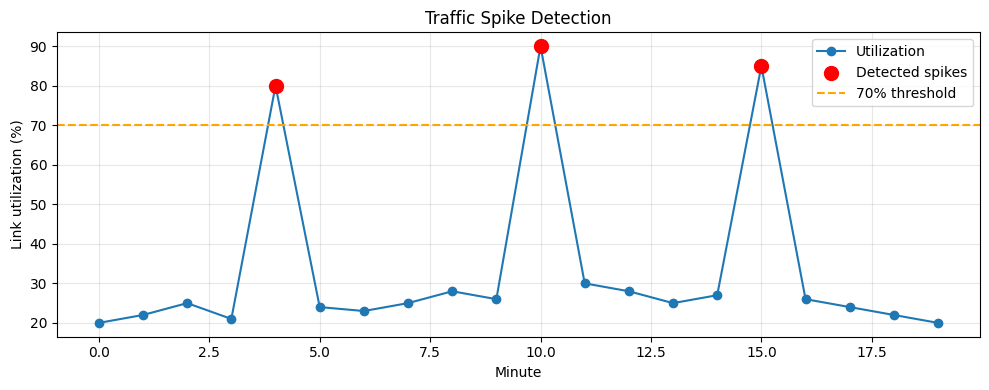

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# One utilization reading per minute.
utilization = np.array([
    20, 22, 25, 21, 80, 24, 23, 25, 28, 26,
    90, 30, 28, 25, 27, 85, 26, 24, 22, 20
])

minutes = np.arange(len(utilization))

peaks, properties = find_peaks(
    utilization,
    height=70,       # Peak must reach at least 70%.
    prominence=30,   # Must stand out by at least 30 percentage points.
    distance=3       # Peaks must be at least 3 samples apart.
)

for index in peaks:
    print(
        f"Spike at minute {minutes[index]}: "
        f"{utilization[index]}% utilization"
    )

plt.figure(figsize=(10, 4))
plt.plot(minutes, utilization, marker="o", label="Utilization")
plt.scatter(
    minutes[peaks],
    utilization[peaks],
    color="red",
    s=100,
    label="Detected spikes",
    zorder=3
)
plt.axhline(70, color="orange", linestyle="--", label="70% threshold")
plt.xlabel("Minute")
plt.ylabel("Link utilization (%)")
plt.title("Traffic Spike Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
from scipy.optimize import linprog

demand_mbps = 120

# Variables:
# x[0] = Mbps assigned to link A
# x[1] = Mbps assigned to link B

result = linprog(
    c=[1, 3],                  # Minimize 1*A + 3*B.
    A_eq=[[1, 1]],             # A + B ...
    b_eq=[demand_mbps],        # ... must equal demand.
    bounds=[(0, 80), (0, 100)],
    method="highs"
)

if result.success:
    link_a, link_b = result.x
    print(f"Link A: {link_a:.1f} Mbps")
    print(f"Link B: {link_b:.1f} Mbps")
    print(f"Total relative cost: {result.fun:.1f}")
else:
    print("No feasible allocation:", result.message)

Link A: 80.0 Mbps
Link B: 40.0 Mbps
Total relative cost: 200.0
